# **1. Dataset Preparation**

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.feature import hog
from sklearn.utils import shuffle
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV, LeaveOneOut
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import cross_val_predict
from mlxtend.data import loadlocal_mnist

In [ ]:
# LOAD DATASET EMNIST LETTERS (BINARY FORMAT)
# Pastikan folder 'dataset/' berisi:
# - emnist-letters-train-images-idx3-ubyte
# - emnist-letters-train-labels-idx1-ubyte

raw_images, raw_labels = loadlocal_mnist(
    images_path='/content/sample_data/emnist-letters-train-images-idx3-ubyte',
    labels_path='/content/sample_data/emnist-letters-train-labels-idx1-ubyte'
)

print("Dataset berhasil dimuat!")
print(f"Jumlah gambar : {len(raw_images)}")
print(f"Jumlah label  : {len(raw_labels)}")

Dataset berhasil dimuat!
Jumlah gambar : 124800
Jumlah label  : 124800


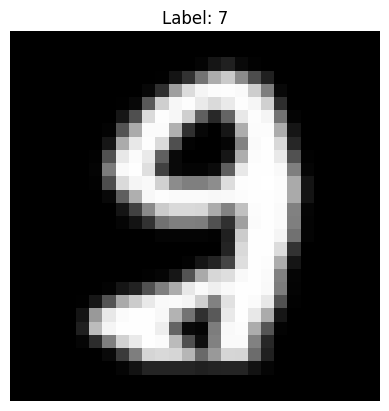

In [ ]:
# TAMPILKAN SATU GAMBAR SECARA ACAK

check_idx = random.randint(0, len(raw_images) - 1)
plt.imshow(raw_images[check_idx].reshape(28, 28).T, cmap='gray')
plt.title(f"Label: {raw_labels[check_idx]}")
plt.axis('off')
plt.show()

In [ ]:
print("Jumlah total gambar:", len(raw_images))
print("Jumlah total label :", len(raw_labels))

Jumlah total gambar: 124800
Jumlah total label : 124800


In [ ]:
# SHIFT LABEL DARI 1-26 MENJADI 0-25
# Agar kompatibel dengan indexing Python (a=0, z=25)

raw_labels = raw_labels - 1

print(f"Range label setelah konversi: {raw_labels.min()} - {raw_labels.max()}")

Range label setelah konversi: 0 - 25


In [ ]:
# AMBIL 100 SAMPEL PER KELAS (26 kelas = 2600)

all_images = np.array(raw_images)
all_labels = np.array(raw_labels)

img_collection  = []
lbl_collection  = []

NUM_CLASSES_TOTAL   = 26
SAMPLE_PER_CLASS    = 100

for cls in range(NUM_CLASSES_TOTAL):
    cls_idx = np.where(all_labels == cls)[0]
    if len(cls_idx) >= SAMPLE_PER_CLASS:
        chosen_idx = np.random.choice(cls_idx, SAMPLE_PER_CLASS, replace=False)
        img_collection.append(all_images[chosen_idx])
        lbl_collection.append(all_labels[chosen_idx])
    else:
        print(f"Kelas {cls} tidak cukup: hanya ada {len(cls_idx)} gambar.")

X_raw = np.vstack(img_collection)
y_raw = np.hstack(lbl_collection)

print(f"Total gambar terpilih : {len(X_raw)}")
print(f"Total label terpilih  : {len(y_raw)}")

Total gambar terpilih : 2600
Total label terpilih  : 2600


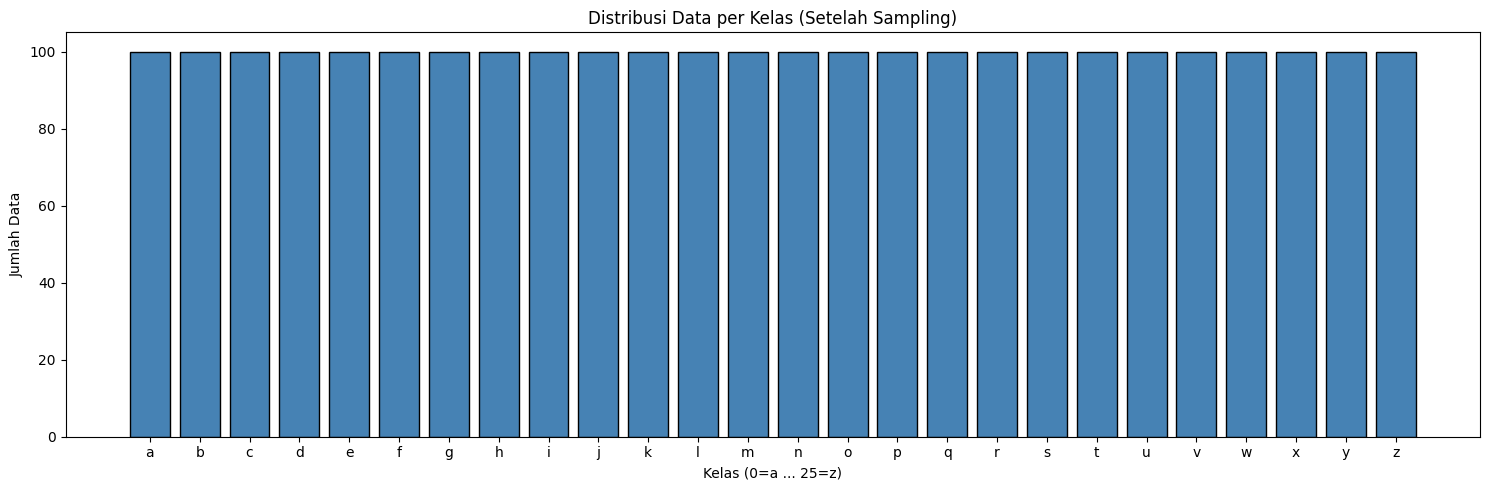

In [ ]:
# BAR CHART: DISTRIBUSI SAMPEL PER KELAS

kelas_unik, jumlah_per_kelas = np.unique(y_raw, return_counts=True)

plt.figure(figsize=(15, 5))
plt.bar(kelas_unik, jumlah_per_kelas, color='steelblue', edgecolor='black')
plt.xlabel('Kelas (0=a ... 25=z)')
plt.ylabel('Jumlah Data')
plt.title('Distribusi Data per Kelas (Setelah Sampling)')
plt.xticks(kelas_unik, [chr(97 + k) for k in kelas_unik])
plt.tight_layout()
plt.show()

In [ ]:
# SHUFFLE DATASET SEBELUM DIPROSES

X_raw, y_raw = shuffle(X_raw, y_raw, random_state=42)

print("Dataset berhasil di-shuffle.")
print(f"Shape X: {X_raw.shape}")
print(f"Shape y: {y_raw.shape}")

Dataset berhasil di-shuffle.
Shape X: (2600, 784)
Shape y: (2600,)


In [ ]:
# SPLIT DATASET: 80% TRAIN / 20% TEST
# Stratified agar distribusi kelas tetap seimbang

X_train, X_test, y_train, y_test = train_test_split(
    X_raw,
    y_raw,
    test_size=0.2,
    random_state=42,
    stratify=y_raw
)

print(f"Jumlah X_train : {len(X_train)}")
print(f"Jumlah y_train : {len(y_train)}")
print(f"Jumlah X_test  : {len(X_test)}")
print(f"Jumlah y_test  : {len(y_test)}")

Jumlah X_train : 2080
Jumlah y_train : 2080
Jumlah X_test  : 520
Jumlah y_test  : 520


# **2. Feature Extraction**

In [ ]:
# CEK BENTUK FITUR HOG PADA SATU GAMBAR
# Parameter diubah dari default:
#   orientations   : 12  (default: 9)
#   pixels_per_cell: (4,4) (sama seperti referensi)
#   cells_per_block: (2,2)
#   block_norm     : 'L2-Hys'

sample_feat, sample_hog_img = hog(
    X_train[0].reshape(28, 28),
    orientations=12,
    pixels_per_cell=(4, 4),
    cells_per_block=(2, 2),
    visualize=True,
    block_norm='L2-Hys'
)

print(f"Panjang vektor HOG: {sample_feat.shape}")

Panjang vektor HOG: (1728,)


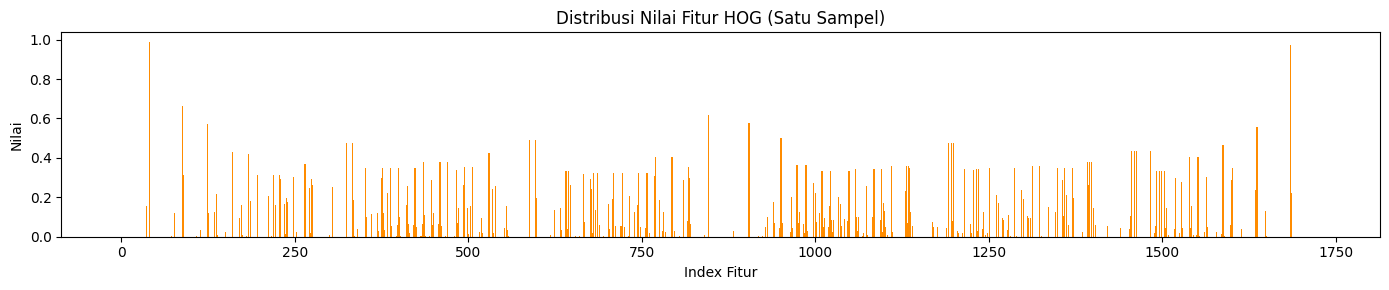

In [ ]:
plt.figure(figsize=(14, 3))
plt.bar(list(range(sample_feat.shape[0])), sample_feat, color='darkorange')
plt.title("Distribusi Nilai Fitur HOG (Satu Sampel)")
plt.xlabel("Index Fitur")
plt.ylabel("Nilai")
plt.tight_layout()
plt.show()

In [ ]:
# FUNGSI HOG FEATURE EXTRACTION
# Diterapkan ke seluruh data train dan test

def compute_hog_features(image_set):
    """Ekstrak fitur HOG dari kumpulan gambar."""
    hog_result = []
    for img in image_set:
        feat_vec = hog(
            img.reshape(28, 28),
            orientations=12,
            pixels_per_cell=(4, 4),
            cells_per_block=(2, 2),
            block_norm='L2-Hys'
        )
        hog_result.append(feat_vec)
    return np.array(hog_result)

In [ ]:
print("Mengekstrak fitur HOG dari data training...")
X_train_hog = compute_hog_features(X_train)

print("Mengekstrak fitur HOG dari data testing...")
X_test_hog  = compute_hog_features(X_test)

print("Selesai!")

Mengekstrak fitur HOG dari data training...
Mengekstrak fitur HOG dari data testing...
Selesai!


In [ ]:
print(f"Shape X_train_hog : {X_train_hog.shape}")
print(f"Shape X_test_hog  : {X_test_hog.shape}")

Shape X_train_hog : (2080, 1728)
Shape X_test_hog  : (520, 1728)


# **3. Classification**

In [ ]:
# PARAMETER GRID UNTUK GRID SEARCH SVM

svm_param_grid = {
    'C'     : [0.01, 0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'gamma' : ['scale', 'auto']
}

In [ ]:
svm_clf   = SVC()
svm_grid  = GridSearchCV(svm_clf, svm_param_grid, cv=5, n_jobs=-1, verbose=2)

In [ ]:
# TRAINING GRID SEARCH
# (Harap tunggu, proses ini memakan waktu)

svm_grid.fit(X_train_hog, y_train)

print(f"\nParameter terbaik : {svm_grid.best_params_}")
print(f"CV Score terbaik  : {svm_grid.best_score_*100:.2f}%")

Fitting 5 folds for each of 40 candidates, totalling 200 fits

Parameter terbaik : {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
CV Score terbaik  : 82.16%


In [ ]:
optimal_model = svm_grid.best_estimator_

print(f"Model terbaik: {optimal_model}")

Model terbaik: SVC(C=10)


# **4. Evaluation**

In [ ]:
# LEAVE-ONE-OUT CROSS VALIDATION (LOOCV)
# Setiap 1 sampel dijadikan data test,
# sisanya dijadikan data training

loocv = LeaveOneOut()

In [20]:
# PREDIKSI LOOCV PADA DATA TRAIN DAN TEST
# cross_val_predict menghasilkan prediksi
# untuk setiap sampel saat dijadikan test set

print("Menjalankan LOOCV pada data training...")
y_pred_train_loo = cross_val_predict(optimal_model, X_train_hog, y_train, cv=loocv)

print("Menjalankan LOOCV pada data testing...")
y_pred_test_loo  = cross_val_predict(optimal_model, X_test_hog,  y_test,  cv=loocv)

print("LOOCV selesai!")

Menjalankan LOOCV pada data training...
Menjalankan LOOCV pada data testing...
LOOCV selesai!


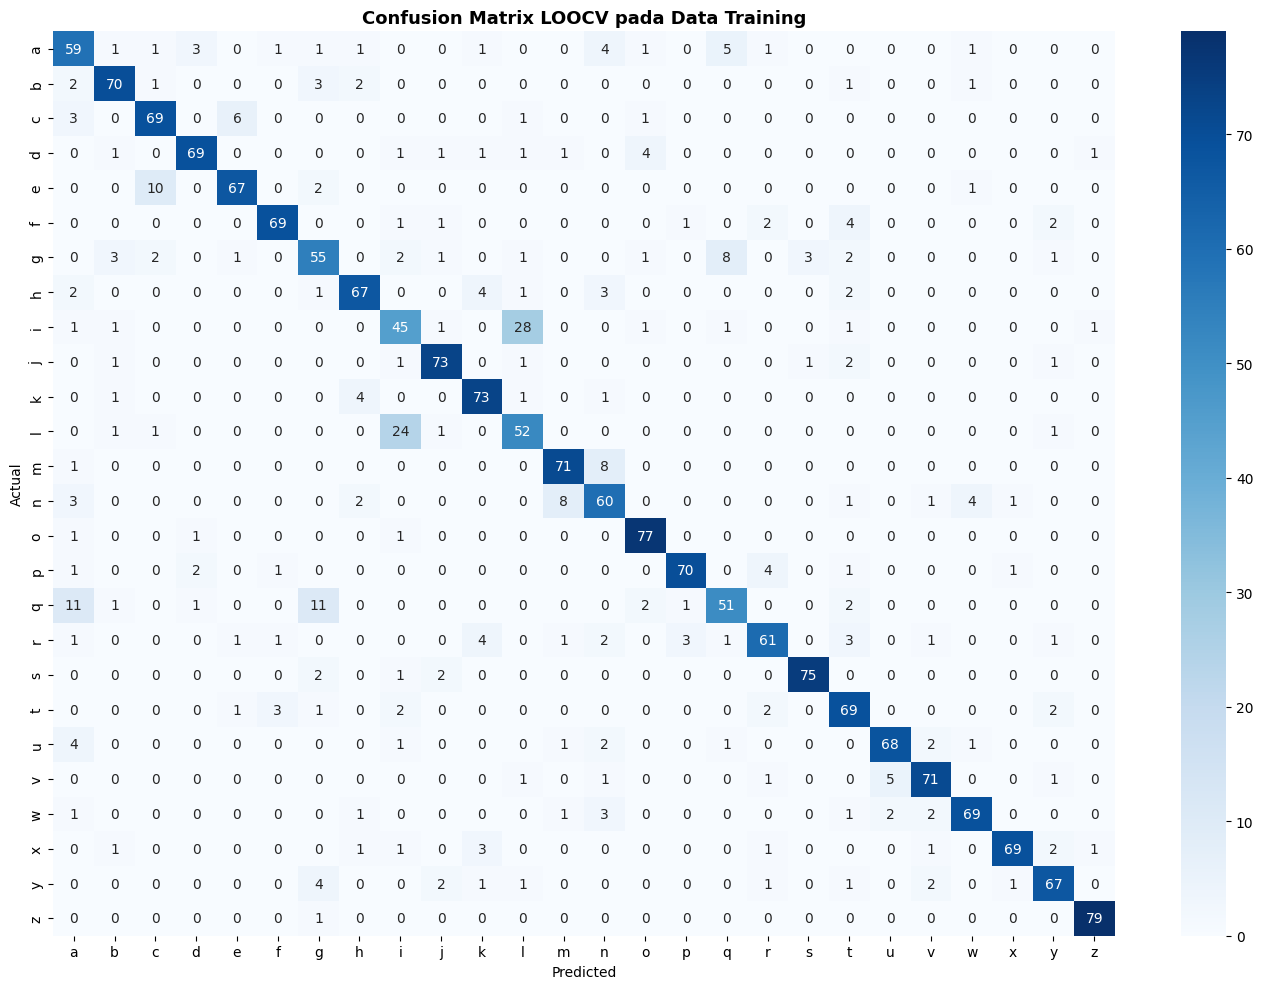

In [21]:
# CONFUSION MATRIX - DATA TRAINING (LOOCV)

cm_hasil_train = confusion_matrix(y_train, y_pred_train_loo)
huruf_label    = [chr(97 + i) for i in range(26)]

plt.figure(figsize=(14, 10))
sns.heatmap(
    cm_hasil_train,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=huruf_label,
    yticklabels=huruf_label
)
plt.title("Confusion Matrix LOOCV pada Data Training", fontsize=13, fontweight='bold')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [22]:
print("=" * 55)
print("   CLASSIFICATION REPORT - DATA TRAINING (LOOCV)")
print("=" * 55)
print(classification_report(y_train, y_pred_train_loo, target_names=huruf_label))

   CLASSIFICATION REPORT - DATA TRAINING (LOOCV)
              precision    recall  f1-score   support

           a       0.66      0.74      0.69        80
           b       0.86      0.88      0.87        80
           c       0.82      0.86      0.84        80
           d       0.91      0.86      0.88        80
           e       0.88      0.84      0.86        80
           f       0.92      0.86      0.89        80
           g       0.68      0.69      0.68        80
           h       0.86      0.84      0.85        80
           i       0.56      0.56      0.56        80
           j       0.89      0.91      0.90        80
           k       0.84      0.91      0.87        80
           l       0.59      0.65      0.62        80
           m       0.86      0.89      0.87        80
           n       0.71      0.75      0.73        80
           o       0.89      0.96      0.92        80
           p       0.93      0.88      0.90        80
           q       0.76      0.6

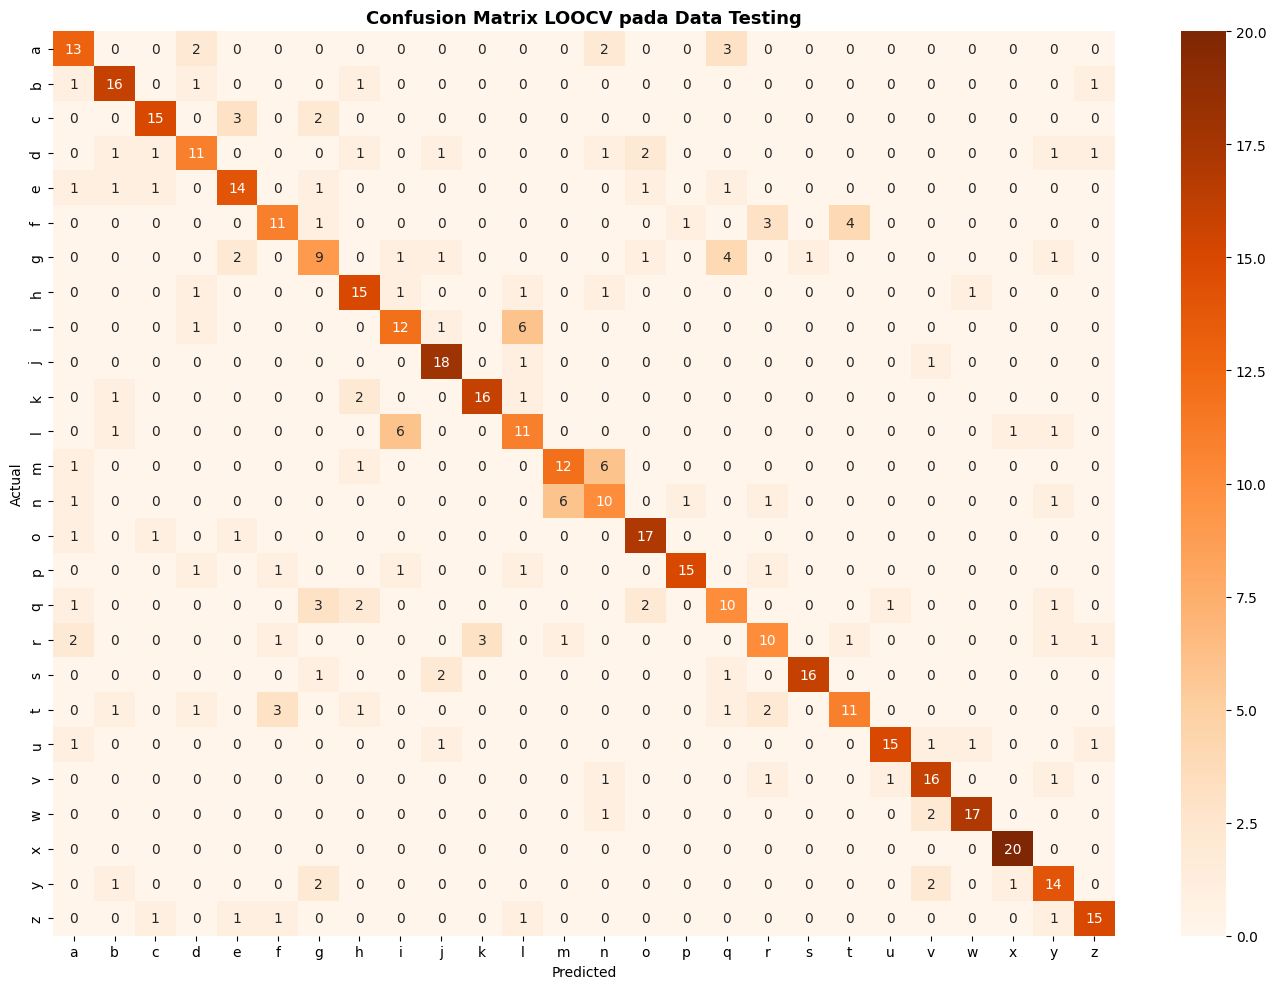

In [23]:
# CONFUSION MATRIX - DATA TESTING (LOOCV)


cm_hasil_test = confusion_matrix(y_test, y_pred_test_loo)

plt.figure(figsize=(14, 10))
sns.heatmap(
    cm_hasil_test,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=huruf_label,
    yticklabels=huruf_label
)
plt.title("Confusion Matrix LOOCV pada Data Testing", fontsize=13, fontweight='bold')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [24]:
print("=" * 55)
print("    CLASSIFICATION REPORT - DATA TESTING (LOOCV)")
print("=" * 55)
print(classification_report(y_test, y_pred_test_loo, target_names=huruf_label))

    CLASSIFICATION REPORT - DATA TESTING (LOOCV)
              precision    recall  f1-score   support

           a       0.59      0.65      0.62        20
           b       0.73      0.80      0.76        20
           c       0.79      0.75      0.77        20
           d       0.61      0.55      0.58        20
           e       0.67      0.70      0.68        20
           f       0.65      0.55      0.59        20
           g       0.47      0.45      0.46        20
           h       0.65      0.75      0.70        20
           i       0.57      0.60      0.59        20
           j       0.75      0.90      0.82        20
           k       0.84      0.80      0.82        20
           l       0.50      0.55      0.52        20
           m       0.63      0.60      0.62        20
           n       0.45      0.50      0.48        20
           o       0.74      0.85      0.79        20
           p       0.88      0.75      0.81        20
           q       0.50      0.5

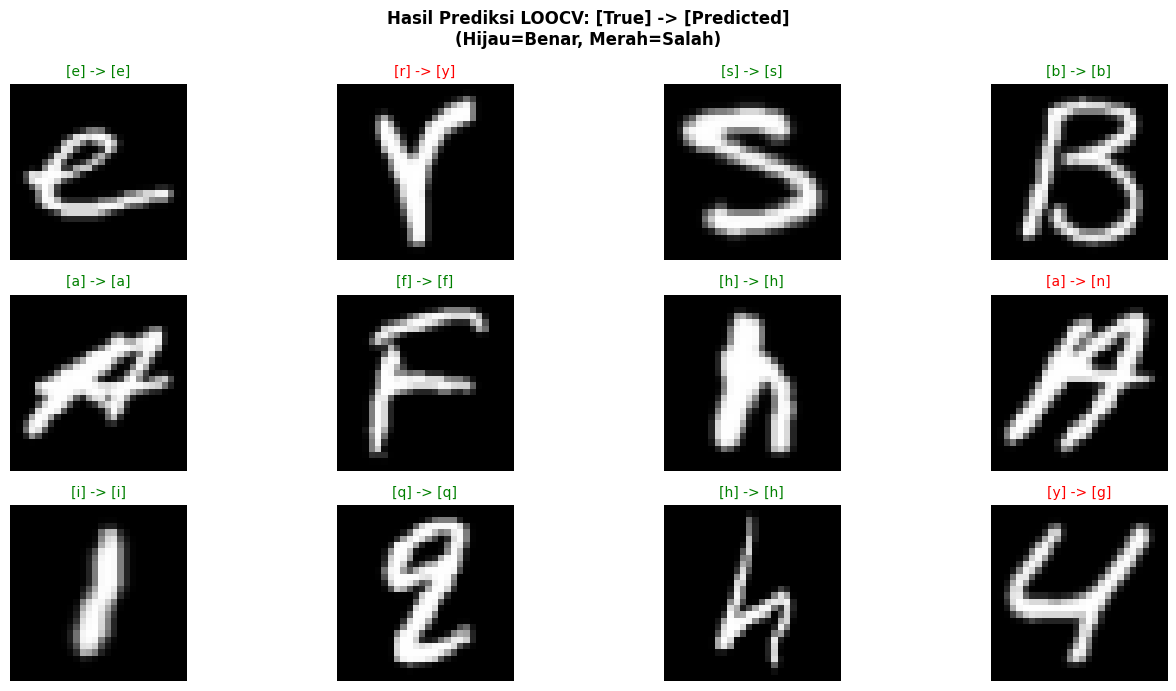

In [25]:
# TAMPILKAN 12 GAMBAR ACAK DARI TEST SET
# Dengan label: [True] -> [Predicted]

tampil_idx = random.sample(range(len(X_test)), 12)

plt.figure(figsize=(14, 7))
for i, idx in enumerate(tampil_idx):
    gambar      = X_test[idx].reshape(28, 28).T
    label_asli  = y_test[idx]
    label_pred  = y_pred_test_loo[idx]

    plt.subplot(3, 4, i + 1)
    plt.imshow(gambar, cmap='gray')
    plt.title(
        f"[{chr(label_asli + 97)}] -> [{chr(label_pred + 97)}]",
        color='green' if label_asli == label_pred else 'red',
        fontsize=10
    )
    plt.axis('off')

plt.suptitle("Hasil Prediksi LOOCV: [True] -> [Predicted]\n(Hijau=Benar, Merah=Salah)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()